In [2]:
import numpy as np
import netket as nk
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt

np.seterr(divide='ignore', invalid='ignore')

{'divide': 'ignore', 'over': 'warn', 'under': 'ignore', 'invalid': 'ignore'}

In [3]:
N          = 12
J          = -1.0
N_HIDDEN   = 2 * N
N_TRAIN    = 5_000
N_OBS      = 20_000
N_EPOCHS   = 4_000
BATCH_SIZE = 100
LR_INIT    = 0.02
LR_FINAL   = 0.005
K_CD       = 1
LOG_EVERY  = 500
N_WARMUP   = 2_000
SEED       = 42

G_VALUES = np.array([
    0.20, 0.40, 0.60,
    0.75, 0.85, 0.95,
    1.00,
    1.05, 1.15, 1.25,
    1.50, 2.00, 3.00,
])

In [4]:
from rbmopt import RBM


class RBM_PCD(RBM):

    def init_from_data(self, dataset):
        M  = len(dataset)
        mu = dataset.mean(axis=0).clip(1e-3, 1 - 1e-3)

        self.b = np.log(mu / (1.0 - mu))

        X         = dataset - mu
        _, S, Vt  = np.linalg.svd(X, full_matrices=False)
        n_comp    = min(self.n_hidden, len(S))

        W_svd = (Vt[:n_comp].T) * (S[:n_comp] / np.sqrt(M)) * 0.1
        if self.n_hidden > n_comp:
            extra = np.random.normal(0, 0.01,
                                     (self.n_visible, self.n_hidden - n_comp))
            self.W = np.hstack([W_svd, extra])
        else:
            self.W = W_svd

        self.c = np.zeros(self.n_hidden)

    def train_pcd(self,
                  dataset,
                  n_epochs      = 1000,
                  batch_size    = 100,
                  lr_init       = 0.05,
                  lr_final      = None,
                  k             = 1,
                  log_every     = 10,
                  kl_mode       = 'samples',
                  psi_prob      = None,
                  hi_states     = None):
        if kl_mode == 'exact' and (psi_prob is None or hi_states is None):
            raise ValueError("kl_mode='exact' requiere psi_prob y hi_states.")

        if lr_final is None:
            lr_final = lr_init

        n_samples       = len(dataset)
        effective_batch = min(batch_size, n_samples)
        rng             = np.random.default_rng(SEED)

        half   = effective_batch // 2
        chains = np.vstack([
            np.ones( (half,                 self.n_visible), dtype=float),
            np.zeros((effective_batch-half, self.n_visible), dtype=float),
        ])

        kl_history = []

        for epoch in range(n_epochs):

            lr = lr_init + (lr_final - lr_init) * epoch / max(n_epochs - 1, 1)

            idx = rng.choice(n_samples, size=effective_batch, replace=False)
            V0  = dataset[idx]

            H0_prob = self.prob_h_given_v(V0)

            Vk = chains
            for _ in range(k):
                Hk = self.sample_h(Vk)
                Vk = self.sample_v(Hk)
            chains = Vk.copy()

            Hk_prob = self.prob_h_given_v(Vk)

            dW = (V0.T @ H0_prob - Vk.T @ Hk_prob) / effective_batch
            db = (V0 - Vk).mean(axis=0)
            dc = (H0_prob - Hk_prob).mean(axis=0)

            self.W += lr * dW
            self.b += lr * db
            self.c += lr * dc

            if epoch % log_every == 0:
                if kl_mode == 'exact':
                    kl = self.kl_divergence_exact(psi_prob, hi_states)
                else:
                    kl = self.kl_divergence_from_samples(dataset)
                kl_history.append((epoch, kl))

        return kl_history

In [5]:
def exact_ground_state(N, h, J=-1.0):
    graph   = nk.graph.Hypercube(length=N, n_dim=1, pbc=True)
    hi      = nk.hilbert.Spin(s=0.5, N=N)
    H_op    = nk.operator.Ising(hilbert=hi, graph=graph, h=h, J=J)
    _, vecs = eigsh(H_op.to_sparse(), k=1, which='SA')
    prob    = np.abs(vecs[:, 0])**2
    return prob / prob.sum(), hi.all_states()

In [6]:
def make_dataset_01(all_states, prob, n_samples, seed=None):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(prob), size=n_samples, p=prob)
    return (all_states[idx] + 1.0) / 2.0


def gibbs_samples_pm1(rbm, n_samples, n_warmup=500, seed=None):
    half  = n_samples // 2
    v     = np.vstack([
        np.ones( (half,           rbm.n_visible), dtype=float),
        np.zeros((n_samples-half, rbm.n_visible), dtype=float),
    ])
    for _ in range(n_warmup):
        h = rbm.sample_h(v)
        v = rbm.sample_v(h)
    return 2.0 * v - 1.0

In [7]:
def observables_from_samples(states_pm1):
    N_   = states_pm1.shape[1]
    m    = states_pm1.mean(axis=1)
    mag  = np.abs(m).mean()
    chi  = N_ * (np.mean(m**2) - mag**2)
    return mag, chi


def observables_exact(all_states, prob):
    N_   = all_states.shape[1]
    m    = all_states.mean(axis=1)
    mag  = np.dot(np.abs(m), prob)
    chi  = N_ * (np.dot(m**2, prob) - mag**2)
    return mag, chi

In [8]:
store = {k: [] for k in ('g', 'e_mag', 'e_chi', 'r_mag', 'r_chi', 'kl')}

print(f"\n{'━'*62}")
print(f"  TFIM Observable Study v3 — init. PCA + bias")
print(f"  N={N}   n_h={N_HIDDEN}   {N_EPOCHS} épocas   PCD-{K_CD}")
print(f"  lr {LR_INIT} → {LR_FINAL} (decay lineal)")
print(f"{'━'*62}")

for g in G_VALUES:
    h = abs(J) * g
    print(f"\n  g = {g:.3f}   (h = {h:.4f})")
    print(f"  {'─'*42}")

    prob, all_states = exact_ground_state(N, h, J)
    e_mag, e_chi     = observables_exact(all_states, prob)
    print(f"  Exact  → |m|={e_mag:.4f}  χ={e_chi:.4f}")

    dataset = make_dataset_01(all_states, prob, N_TRAIN, seed=SEED)

    rbm = RBM_PCD(n_visible=N, n_hidden=N_HIDDEN, seed=SEED)
    rbm.init_from_data(dataset)

    kl_hist = rbm.train_pcd(
        dataset,
        n_epochs  = N_EPOCHS,
        batch_size= BATCH_SIZE,
        lr_init   = LR_INIT,
        lr_final  = LR_FINAL,
        k         = K_CD,
        log_every = LOG_EVERY,
        kl_mode   = 'exact',
        psi_prob  = prob,
        hi_states = all_states,
    )
    kl_0, kl_fin = kl_hist[0][1], kl_hist[-1][1]
    arrow = '↓' if kl_fin < kl_0 else '↑'
    print(f"  KL     → {kl_0:.5f} → {kl_fin:.5f}  ({arrow})")

    rbm_pm1      = gibbs_samples_pm1(rbm, N_OBS, N_WARMUP, seed=SEED)
    r_mag, r_chi = observables_from_samples(rbm_pm1)
    print(f"  RBM    → |m|={r_mag:.4f}  χ={r_chi:.4f}")

    store['g'].append(g)
    store['e_mag'].append(e_mag); store['e_chi'].append(e_chi)
    store['r_mag'].append(r_mag); store['r_chi'].append(r_chi)
    store['kl'].append(kl_fin)

store = {k: np.array(v) for k, v in store.items()}
print(f"\n{'━'*62}")
print("  Entrenamiento completo. Generando figura …")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TFIM Observable Study v3 — init. PCA + bias
  N=12   n_h=24   4000 épocas   PCD-1
  lr 0.02 → 0.005 (decay lineal)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  g = 0.200   (h = 0.2000)
  ──────────────────────────────────────────
  Exact  → |m|=0.9949  χ=0.0103
  KL     → 7.41264 → 2.50728  (↓)
  RBM    → |m|=0.9678  χ=0.0720

  g = 0.400   (h = 0.4000)
  ──────────────────────────────────────────
  Exact  → |m|=0.9784  χ=0.0456
  KL     → 6.91380 → 0.26909  (↓)
  RBM    → |m|=0.9459  χ=0.1440

  g = 0.600   (h = 0.6000)
  ──────────────────────────────────────────
  Exact  → |m|=0.9454  χ=0.1280
  KL     → 6.14855 → 0.19763  (↓)
  RBM    → |m|=0.9156  χ=0.2486

  g = 0.750   (h = 0.7500)
  ──────────────────────────────────────────
  Exact  → |m|=0.8980  χ=0.2835
  KL     → 5.30722 → 0.43632  (↓)
  RBM    → |m|=0.8635  χ=0.4264

  g = 0.850   (h = 0.8500)
  ──────────────────────────────────────────

  → tfim_observables_v3.png


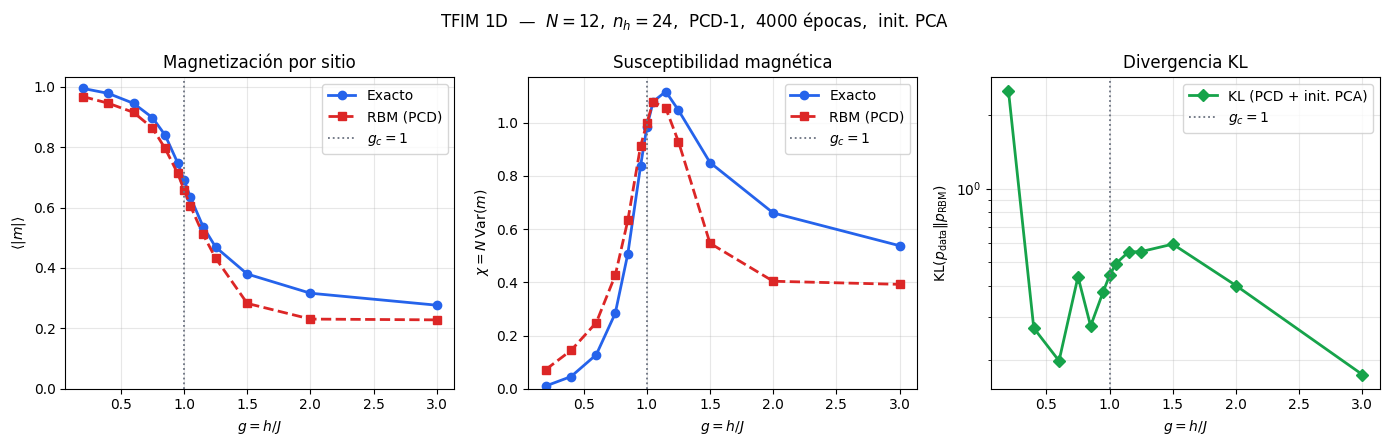


Hecho.


In [11]:
g     = store['g']
BLUE  = '#2563EB'
RED   = '#DC2626'
GREEN = '#16A34A'
G_C   = 1.0

kw_e = dict(color=BLUE, marker='o', ms=6, lw=2.0, label='Exacto')
kw_r = dict(color=RED,  marker='s', ms=6, lw=2.0, ls='--', label='RBM (PCD)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle(
    rf'TFIM 1D  —  $N={N},\;n_h={N_HIDDEN}$,  PCD-{K_CD},  {N_EPOCHS} épocas,  init. PCA',
    fontsize=12
)

def add_gc(ax):
    ax.axvline(G_C, color='#6B7280', ls=':', lw=1.3, label='$g_c = 1$')

ax = axes[0]
ax.plot(g, store['e_mag'], **kw_e)
ax.plot(g, store['r_mag'], **kw_r)
add_gc(ax)
ax.set(xlabel='$g = h/J$',
       ylabel=r'$\langle |m| \rangle$',
       title='Magnetización por sitio',
       ylim=(0, None))
ax.legend(framealpha=0.8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(g, store['e_chi'], **kw_e)
ax.plot(g, store['r_chi'], **kw_r)
add_gc(ax)
ax.set(xlabel='$g = h/J$',
       ylabel=r'$\chi = N\,\mathrm{Var}(m)$',
       title='Susceptibilidad magnética',
       ylim=(0, None))
ax.legend(framealpha=0.8)
ax.grid(alpha=0.3)

ax = axes[2]
ax.semilogy(g, store['kl'], color=GREEN, marker='D', ms=6, lw=2.0,
            label='KL (PCD + init. PCA)')
add_gc(ax)
ax.set(xlabel='$g = h/J$',
       ylabel=r'$\mathrm{KL}(p_{\rm data} \| p_{\rm RBM})$',
       title='Divergencia KL')
ax.legend(framealpha=0.8)
ax.grid(alpha=0.3, which='both')

fig.tight_layout()
fig.savefig('tfim_observables_v3.png', dpi=150, bbox_inches='tight')
print("  → tfim_observables_v3.png")
plt.show()
print("\nHecho.")

In [10]:
import os

output_dir  = r'C:\Users\samur\OneDrive\Escritorio\Python\TFG\Datos'
output_path = os.path.join(output_dir, 'observables_1_capa_NQS.txt')

os.makedirs(output_dir, exist_ok=True)

header = (
    f"# TFIM 1D — Observables NQS (1 capa RBM, PCD)\n"
    f"# N={N}   n_h={N_HIDDEN}   {N_EPOCHS} épocas   PCD-{K_CD}\n"
    f"# lr {LR_INIT} → {LR_FINAL}   seed={SEED}\n"
    f"#\n"
    f"# {'g':>10}   {'mag_exacta':>14}   {'chi_exacta':>14}   "
    f"{'mag_RBM':>14}   {'chi_RBM':>14}\n"
)

with open(output_path, 'w', encoding='utf-8') as fout:
    fout.write(header)
    for i in range(len(store['g'])):
        fout.write(
            f"  {store['g'][i]:>10.4f}   "
            f"{store['e_mag'][i]:>14.8f}   "
            f"{store['e_chi'][i]:>14.8f}   "
            f"{store['r_mag'][i]:>14.8f}   "
            f"{store['r_chi'][i]:>14.8f}\n"
        )

print(f"Datos guardados en:\n  {output_path}")
print(f"  {len(store['g'])} filas escritas.")


Datos guardados en:
  C:\Users\samur\OneDrive\Escritorio\Python\TFG\Datos\observables_1_capa_NQS.txt
  13 filas escritas.
